# TensorFlow: Structural Time Series Forecasting

This notebook demonstrates a complete end-to-end time series forecasting
pipeline using **TensorFlow Probability's Structural Time Series (STS)**
module.

**Workflow:**
1. Generate a synthetic daily time series with trend, seasonality, holidays,
   and autoregressive noise
2. Build an STS model combining multiple interpretable components
3. Fit the model via Variational Inference (VI)
4. Forecast future values and evaluate performance

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import logging

import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import sklearn.metrics as metrics
import tensorflow_probability as tfp
import tf_keras

import tensorflow_utils as tteteuti

_LOG = logging.getLogger(__name__)

2026-03-10 16:28:44.100240: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-10 16:28:44.100451: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-10 16:28:44.137759: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-03-10 16:28:45.032141: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-10 16:28:45.032394: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Config

All model and data parameters are centralised here so the notebook can be
reproduced by changing a single dictionary.

In [2]:
config = {
    # Train / test split.
    "train_start_date": "2020-01-01",
    "train_end_date": "2023-12-31",
    "test_start_date": "2024-01-01",
    "test_end_date": "2024-12-31",
    "data": {
        # Linear trend.
        "slope": 0.005,
        "intercept": 15,
        # Weekly seasonal drift.
        "seasonal_drift_scale": 0.5,
        # Holiday dates and their additive impact.
        "holidays_dates": [
            "2020-12-25",
            "2021-12-25",
            "2022-12-25",
            "2023-12-25",
            "2024-12-25",
        ],
        "holidays_impact": 0.25,
        # AR(1) coefficient.
        "ar_order": 1,
        "phi": 0.7,
        # Observation noise.
        "seed": 42,
        "observational_noise_sigma": 2.0,
    },
    "model": {
        # Weekly seasonality: 7 seasons, 1 step each.
        "num_seasons": 7,
        "num_steps_per_season": 1,
        "learning_rate": 0.1,
        # Number of VI optimisation steps.
        "num_steps": 200,
    },
}
print(config)

{'train_start_date': '2020-01-01', 'train_end_date': '2023-12-31', 'test_start_date': '2024-01-01', 'test_end_date': '2024-12-31', 'data': {'slope': 0.005, 'intercept': 15, 'seasonal_drift_scale': 0.5, 'holidays_dates': ['2020-12-25', '2021-12-25', '2022-12-25', '2023-12-25', '2024-12-25'], 'holidays_impact': 0.25, 'ar_order': 1, 'phi': 0.7, 'seed': 42, 'observational_noise_sigma': 2.0}, 'model': {'num_seasons': 7, 'num_steps_per_season': 1, 'learning_rate': 0.1, 'num_steps': 200}}


## Part 1: Data Generation

We generate a realistic synthetic daily time series that combines:
- A **linear trend** (slow upward drift)
- **Weekly seasonality** with stochastic drift
- **Holiday effects** (additive spikes on Christmas each year)
- **AR(1) autoregression** to capture temporal dependence
- **Gaussian observation noise**

Using synthetic data lets us later verify that the model recovers the known
ground-truth parameters.

In [3]:
df = tteteuti.generate_time_series_data(config)
_LOG.info(tteteuti.df_to_str_simple(df))

<Axes: title={'center': 'Synthetic Daily Time Series'}, xlabel='Date', ylabel='Target variable'>

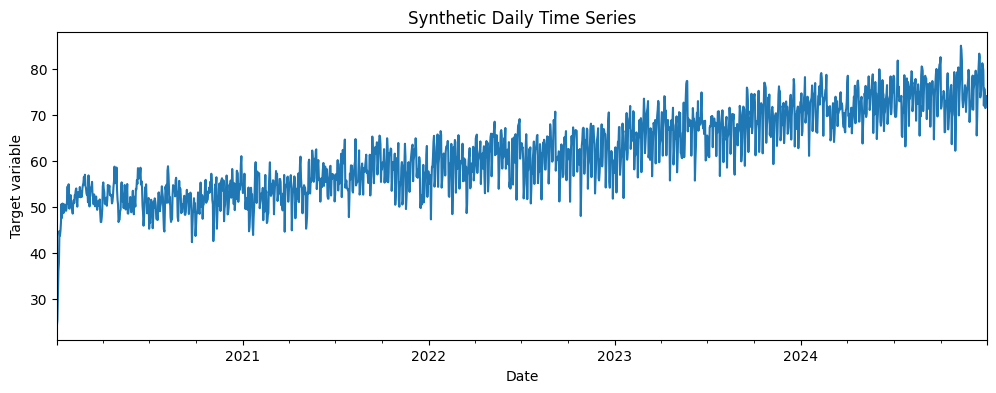

In [4]:
df.set_index("ds")["y"].plot(
    title="Synthetic Daily Time Series",
    ylabel="Target variable",
    xlabel="Date",
    figsize=(12, 4),
)

In [5]:
# Split into train and test sets.
train_mask = (df["ds"] >= config["train_start_date"]) & (
    df["ds"] <= config["train_end_date"]
)
test_mask = (df["ds"] >= config["test_start_date"]) & (
    df["ds"] <= config["test_end_date"]
)
df_train = df[train_mask].reset_index(drop=True)
df_test = df[test_mask].reset_index(drop=True)
_LOG.info("Train rows=%d, Test rows=%d", len(df_train), len(df_test))

## Part 2: Model Building

The STS model decomposes the observed series into four interpretable
components:

| Component | Purpose |
|---|---|
| `LocalLinearTrend` | Captures slow-moving level and slope |
| `Seasonal` (7 seasons) | Weekly day-of-week effects |
| `Autoregressive` (AR-1) | Short-term temporal dependence |
| `LinearRegression` | Additive holiday spikes |

The components are summed into a `tfp.sts.Sum` model.

In [6]:
# Build one-hot holiday indicator matrix for the full date range.
holiday_indicators = tteteuti.build_holiday_indicators(config)
_LOG.info("holiday_indicators shape=%s", holiday_indicators.shape)

In [7]:
model = tteteuti.build_sts_model(
    df_train["y"].to_numpy(), holiday_indicators, config
)

2026-03-10 16:28:45.987563: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### Variational Inference

We approximate the posterior over model parameters using **Variational
Inference (VI)**:
1. Define a factored surrogate posterior `q(θ)` (one Normal per parameter)
2. Maximise the ELBO: `ELBO = E_q[log p(y, θ)] - KL(q || prior)`
3. Use the Adam optimiser for gradient-based optimisation

In [8]:
# Build the variational surrogate posteriors.
variational_posteriors = tfp.sts.build_factored_surrogate_posterior(model=model)

2026-03-10 16:28:56.234079: I external/local_xla/xla/service/service.cc:163] XLA service 0x5f6172061690 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2026-03-10 16:28:56.234093: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Host, Default Version
2026-03-10 16:28:56.419096: W tensorflow/compiler/tf2xla/kernels/random_ops.cc:108] Warning: Using tf.random.uniform with XLA compilation will ignore seeds; consider using tf.random.stateless_uniform instead if reproducible behavior is desired. fit_surrogate_posterior/StatefulPartitionedCall/monte_carlo_variational_loss/split_seed/sanitize_seed/seed
2026-03-10 16:28:56.433183: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


I0000 00:00:1773160141.177601     216 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


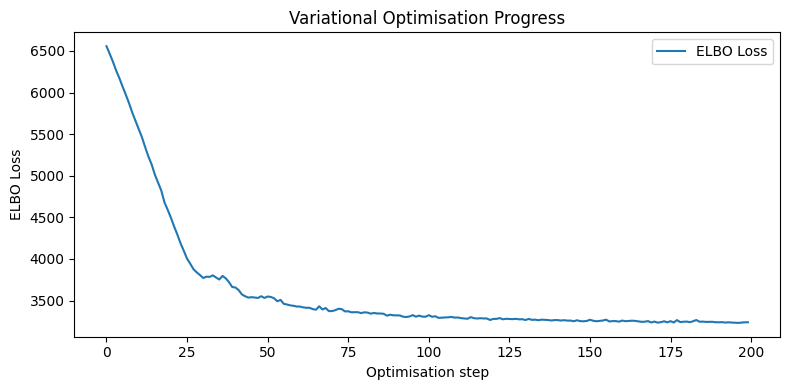

In [9]:
elbo_loss_curve = tfp.vi.fit_surrogate_posterior(
    target_log_prob_fn=model.joint_distribution(
        observed_time_series=df_train["y"].to_numpy()
    ).log_prob,
    surrogate_posterior=variational_posteriors,
    optimizer=tf_keras.optimizers.Adam(
        learning_rate=config["model"]["learning_rate"]
    ),
    num_steps=config["model"]["num_steps"],
    jit_compile=True,
)
plt.figure(figsize=(8, 4))
plt.plot(elbo_loss_curve, label="ELBO Loss")
plt.xlabel("Optimisation step")
plt.ylabel("ELBO Loss")
plt.title("Variational Optimisation Progress")
plt.legend()
plt.tight_layout()

In [10]:
# Draw posterior samples.
q_samples_ = variational_posteriors.sample(50)

In [11]:
# Report inferred parameter values.
_LOG.info("Inferred parameters:")
for param in model.parameters:
    _LOG.info(
        "  %s: %.4f ± %.4f",
        param.name,
        np.mean(q_samples_[param.name], axis=0),
        np.std(q_samples_[param.name], axis=0),
    )

## Part 3: Forecasting and Evaluation

With the fitted posterior we:
1. Decompose the training signal into its constituent components
2. Forecast `num_steps_forecast` steps into the future
3. Evaluate using MAE and MSE

In [12]:
# Decompose training data into components.
component_dists = tfp.sts.decompose_by_component(
    model,
    observed_time_series=df_train["y"].to_numpy(),
    parameter_samples=q_samples_,
)
component_means_ = {k.name: c.mean() for k, c in component_dists.items()}
component_stddevs_ = {k.name: c.stddev() for k, c in component_dists.items()}

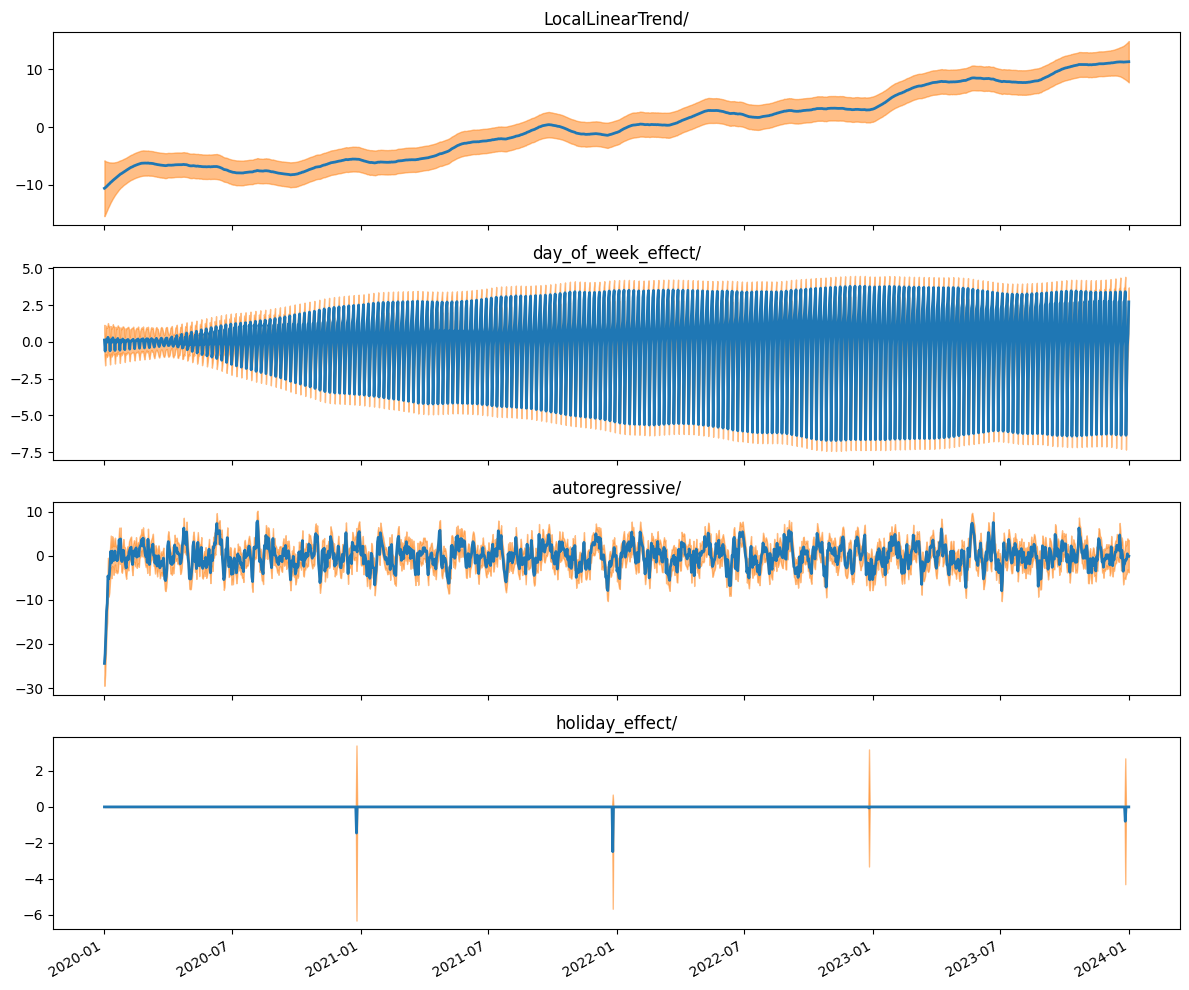

In [13]:
_ = tteteuti.plot_components(
    df_train["ds"], component_means_, component_stddevs_
)

In [14]:
# Forecast the test period.
forecast_dist = tfp.sts.forecast(
    model=model,
    observed_time_series=df_train["y"].to_numpy(),
    parameter_samples=q_samples_,
    num_steps_forecast=len(df_test),
)
num_samples = 10
forecast_mean = forecast_dist.mean().numpy()[..., 0]
forecast_scale = forecast_dist.stddev().numpy()[..., 0]
forecast_samples = forecast_dist.sample(num_samples).numpy()[..., 0]

2026-03-10 16:29:09.191232: E tensorflow/core/util/util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


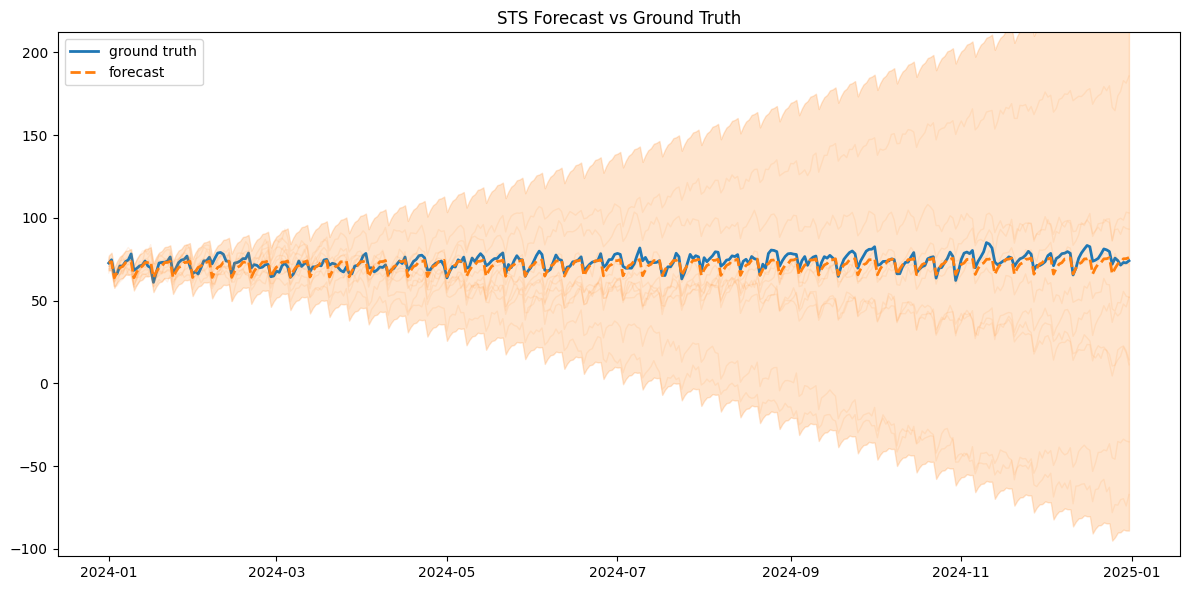

In [15]:
fig, ax = tteteuti.plot_forecast(
    df_test["ds"],
    df_test["y"].to_numpy(),
    forecast_mean,
    forecast_scale,
    forecast_samples,
    title="STS Forecast vs Ground Truth",
)
fig.tight_layout()

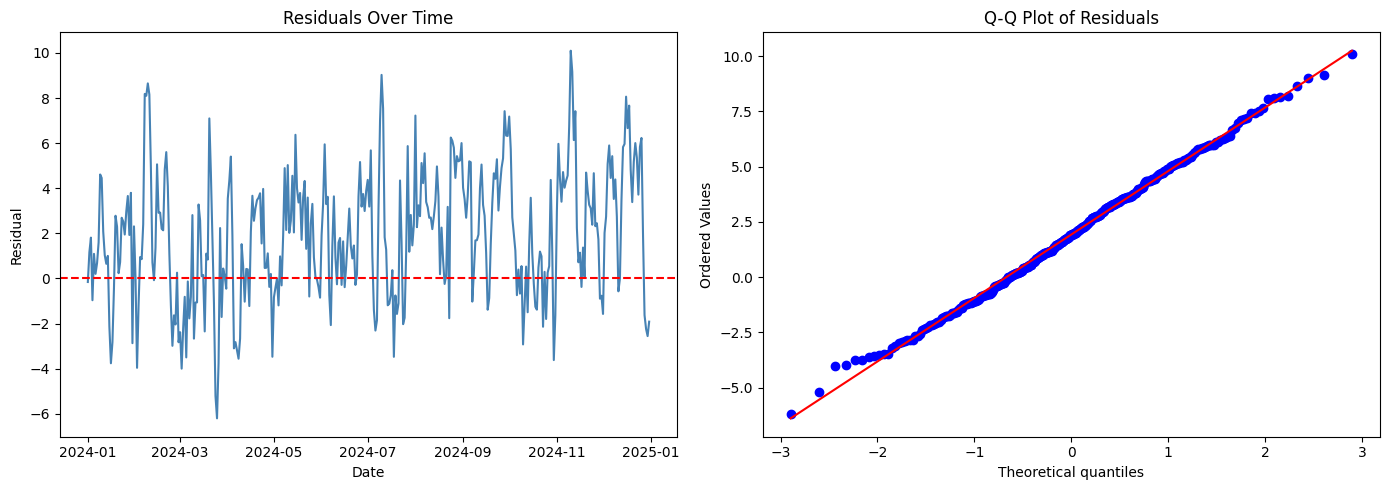

In [16]:
# Residual analysis.
residuals = df_test["y"].to_numpy() - forecast_mean
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(df_test["ds"], residuals, color="steelblue")
axes[0].axhline(0, color="red", ls="--")
axes[0].set_title("Residuals Over Time")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Residual")
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot of Residuals")
plt.tight_layout()

In [17]:
# Performance metrics.
mae = metrics.mean_absolute_error(df_test["y"].to_numpy(), forecast_mean)
mse = metrics.mean_squared_error(df_test["y"].to_numpy(), forecast_mean)
_LOG.info("MAE=%.4f", mae)
_LOG.info("MSE=%.4f", mse)